### 4.5 Scenario Engine — SVAR shocks meet the Ensemble

$$\Delta_h = \text{shock}\times \mathrm{IRF}_h(\text{driver}\to\text{target}),\quad
\text{shock} = \text{input} - \mathrm{SVAR}_{h=1}$$

$$\hat y^{*}_{h,i} = \hat y_{ens,h,i} + \Delta_{h,i}$$

Only the *surprise* over SVAR's own horizon-1 forecast counts, so the expected macro path
is never double-counted; draws are paired index-for-index (Ensemble draw $i$ with SVAR
bootstrap draw $i$), never randomly matched. Because the shock lands at $t{+}1$, CPI
horizon $h$ receives IRF index $h-1$.

This is the forward-looking counterpart to [§4.4](44_svar)'s historical-decomposition walkthrough — it applies the *same* fitted IRF machinery prospectively (hypothetical shock → future path) rather than retrospectively (actual path → attributed shocks). Compare the two: [§4.4](44_svar)'s real 2021Q1 downside surprise in trimmed-mean inflation was mostly a lagged unemployment effect, not a fresh policy or commodity shock — exactly the kind of *SVAR-anticipated* move this section's $\text{shock} = \text{input} - \mathrm{SVAR}_{h=1}$ term is built to net out before a hypothetical scenario moves anything.

*Source: `src/models/scenario.py`, served at `POST /forecast/scenario`*

#### Explained, step by step

- `input` is the number typed into the shock box (e.g. "unemployment ends up at 5.0%"). The model doesn't use that raw number directly — it first subtracts what SVAR *already expected* for that same variable one quarter ahead ($\mathrm{SVAR}_{h=1}$). What's left, `shock`, is only the **surprise**: the part of the scenario SVAR's own baseline forecast didn't already anticipate. This matters because typing in exactly what SVAR expected anyway isn't a "shock" at all — it should move nothing.
- $\mathrm{IRF}_h(\text{driver}\to\text{target})$ is the impulse-response value from [§4.4](44_svar) — how many percentage points the target variable moves, $h$ quarters after a one-unit shock to the driver variable. Multiplying the surprise by this per-horizon sensitivity gives $\Delta_h$, the scenario's structural adjustment at horizon $h$.
- $\Delta_h$ is added on top of the Ensemble's own Monte-Carlo forecast draws $\hat y_{ens,h,i}$ for draw $i$ ([§4.3](43_ensemble)'s 1,000 simulated paths, not just one number), giving a shocked version of that same draw, $\hat y^{*}_{h,i}$. The subscript $i$ is preserved deliberately — "paired index-for-index, never randomly matched" — so draw #37's shocked path is still draw #37's *own* baseline path plus the shock, not a randomly re-shuffled combination that would misrepresent the resulting uncertainty band.
- In one sentence: take a hypothesized scenario, strip out the part SVAR already saw coming, convert the leftover surprise into a CPI effect using SVAR's own estimated sensitivity, and lay that effect on top of the Ensemble's existing uncertainty fan rather than replacing it.

**Static example runs.** `POST /forecast/scenario` accepts any shock variable and size, so a fixed book page can only illustrate a couple of fixed cases rather than the full input space. Two canned examples below, both for the trimmed-mean target, forecast origin 2025Q4, `n_sims=300`:

| Case | Shock variable | Input level | Surprise vs. SVAR's own h=1 forecast |
|---|---|---|---|
| Unemployment surprise | `unemployment_rate` | 5.0% | +0.69pp |
| Cash rate surprise | `cash_rate` | 5.0% | +1.40pp |

Notice the cash-rate surprise (+1.40pp) moves the mean forecast further than the unemployment surprise (+0.69pp) mostly because it is the larger *surprise* in this pair, not because a rate shock is inherently more powerful per-unit than an unemployment shock — the two aren't on a comparable per-unit footing here, since each row's surprise size is whatever was left after subtracting SVAR's own horizon-1 expectation for that specific variable.

```{tip}
To run your **own** shock variable and size against the live SVAR + Ensemble pipeline, run `streamlit run app/streamlit_app.py` from the project root and open **4.5 Scenario Engine** (needs the FastAPI backend reachable at the configured API base URL).
```

Unemployment surprise: shock=+0.69pp, h1=3.28%, h8=3.11% | Cash rate surprise: shock=+1.40pp, h1=3.32%, h8=3.23%


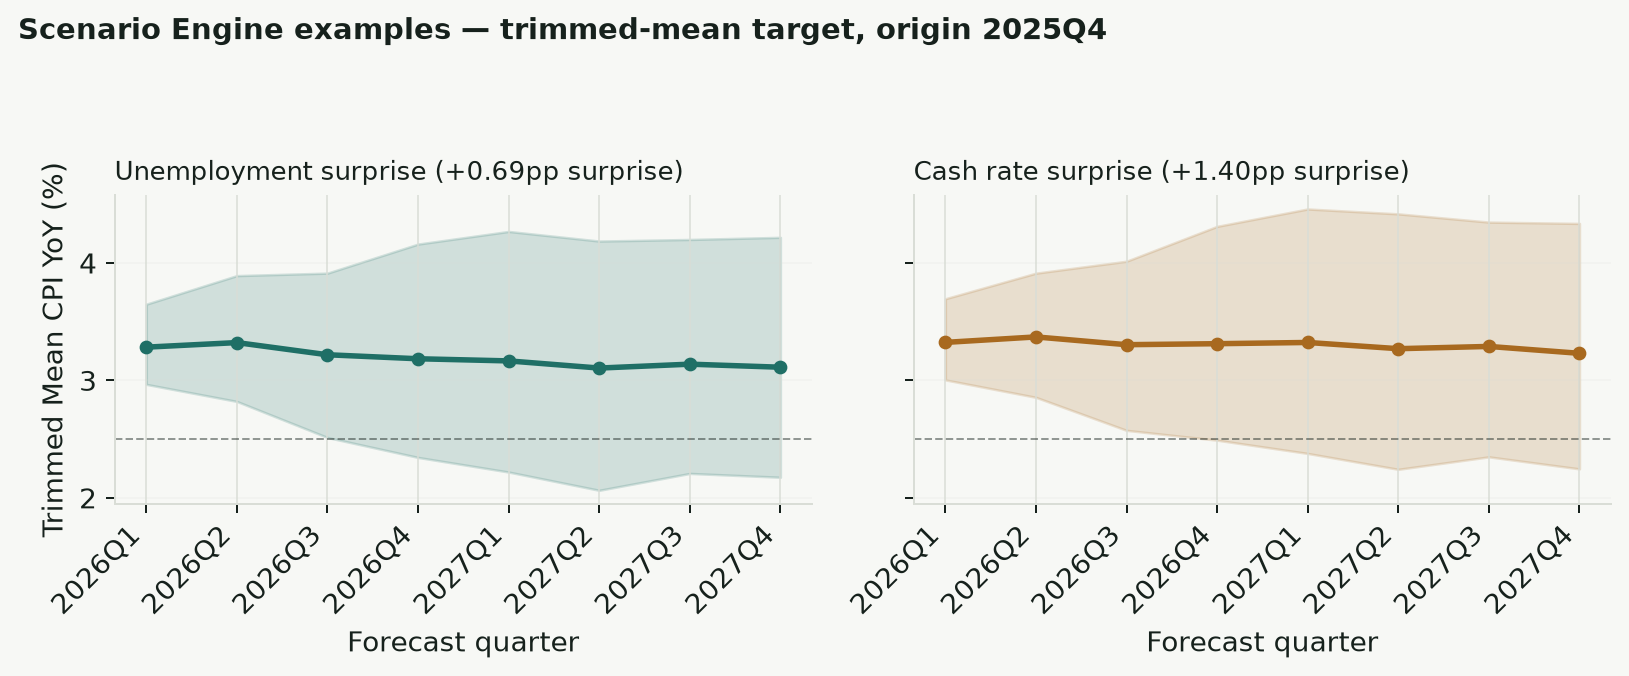

In [2]:
from src.models import scenario

SCENARIO_CASES = (
    ("Unemployment surprise", "unemployment_rate", 5.0),
    ("Cash rate surprise", "cash_rate", 5.0),
)
scenario_results = [
    scenario.run_scenario(
        target="trimmed_mean",
        shock_variable=shock_variable,
        shock_value=shock_value,
        n_sims=300,
        seed=42,
    )
    for _, shock_variable, shock_value in SCENARIO_CASES
]

fig, axes = plt.subplots(1, 2, figsize=(9.2, 3.8), sharey=True)
for ax, (label, shock_variable, shock_value), result, color in zip(
    axes, SCENARIO_CASES, scenario_results, (ACCENT, HIGHLIGHT)
):
    x = np.arange(len(result.horizons))
    ax.fill_between(x, result.interval_lower, result.interval_upper, color=color, alpha=0.18)
    ax.plot(x, result.forecast, color=color, linewidth=2.2, marker="o", markersize=4.5)
    ax.set_xticks(x, result.quarters, rotation=45, ha="right")
    ax.axhline(2.5, color=INK, linewidth=0.8, linestyle="--", alpha=0.45)
    ax.set_title(f"{label} ({result.shock_size:+.2f}pp surprise)", fontsize=10.5, loc="left")
    ax.set_xlabel("Forecast quarter")
    ax.grid(True, axis="y", alpha=0.18, linewidth=0.7)
    ax.spines[["top", "right"]].set_visible(False)
axes[0].set_ylabel("Trimmed Mean CPI YoY (%)")
fig.suptitle(
    "Scenario Engine examples — trimmed-mean target, origin 2025Q4",
    fontsize=11.5,
    fontweight="bold",
    x=0.02,
    ha="left",
)
fig.tight_layout(rect=(0, 0, 1, 0.9))
scenario_path = PROJECT_ROOT / "book/australian_cpi_forecasting/_static/scenario_examples.png"
fig.savefig(scenario_path, dpi=180, bbox_inches="tight")
plt.close(fig)

print(
    " | ".join(
        f"{label}: shock={result.shock_size:+.2f}pp, h1={result.forecast[0]:.2f}%, h8={result.forecast[-1]:.2f}%"
        for (label, _, _), result in zip(SCENARIO_CASES, scenario_results)
    )
)
Image(filename=str(scenario_path))
